In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 15})

We will work through the same example using the Tensorflow, PyTorch, and JAX backends.

## Tensorflow

### Target log probability
Takes tensor of (n_walkers, n_parameters) input parameter vectors, return shape (n_walkers,) i.e., the log probability for each of the input parameter vectors

In [2]:
# import tf version
import tensorflow as tf
from affine.tensorflow import affine_sample

# target log probability
@tf.function
def log_prob(theta):
    
    # seperate out parameters
    x, y = tf.split(theta, (1,1), axis=-1)
    
    # rosenbrock function
    return -tf.squeeze(tf.divide(tf.square(1. - x) + tf.multiply(100., tf.square(y - tf.square(x))), 20.), -1)

### Initialize the walkers
You need to initialize *two* sets of "walkers", each of shape (n_walkers, n_parameters), for the parallel affine sampler. It's generally a good idea to initialize walkers in a tight-ish ball close to some fiducial parameter guess (and the sampler will burn in from there). The two sets of walkers (put into a list) define the initial "current state" for the sampler.

In [3]:
# number of parameters
n_params = 2

# number of walkers (note you'll end up with a total of 2*n_walkers for this parallel variant of the affine sampler)
n_walkers = 500

# initialize walkers and current state
walkers1 = tf.random.normal([n_walkers, n_params], 0., 1.)
walkers2 = tf.random.normal([n_walkers, n_params], 0., 1.)
current_state = [walkers1, walkers2]

### Run the sampler!

In [4]:
# number of MCMC steps to take (you'll end up with an MCMC chain with shape (n_steps, 2*n_walkers, n_parameters))
n_steps = 300

# run the sampler
chain = affine_sample(log_prob, n_steps, current_state, args=[])

2026-10-02 15:02:47.630445: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz
100%|█████████████████████████████████████| 299/299 [00:00<00:00, 726.89it/s]


### Plot the results

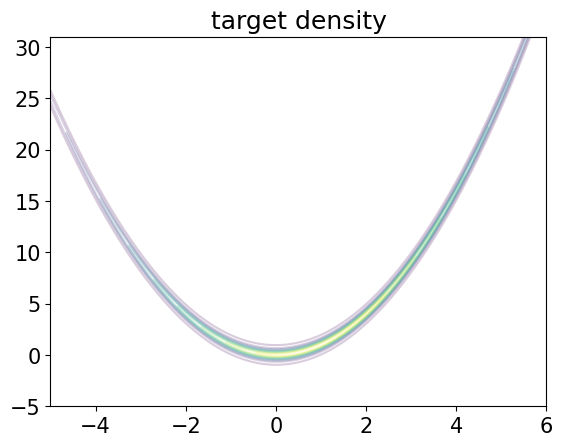

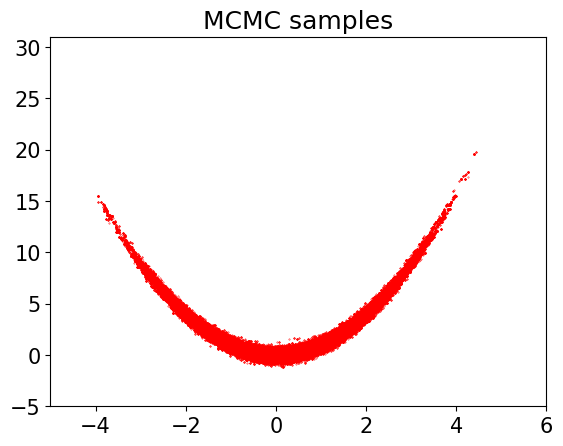

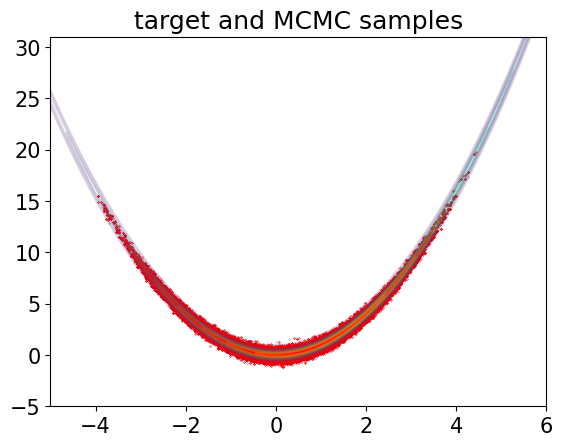

In [5]:
# plot the results...

# how many burnin steps to remove
burnin_steps = 100

# plot the target density
x = np.linspace(-5, 6, 500).astype(np.float32)
y = np.linspace(-5, 31, 500).astype(np.float32)
X, Y = np.meshgrid(x, y)
grid = tf.stack([X, Y], axis=-1)
L = tf.exp(log_prob(grid)).numpy()
plt.contour(x, y, L, levels = np.array([0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])*np.max(L.flatten()).astype(np.float64), alpha = 0.2)
plt.title('target density')
plt.show()

# scatter
plt.title('MCMC samples')
plt.scatter(chain.numpy()[burnin_steps:,:,0], chain.numpy()[burnin_steps:,:,1], s = 0.1, color = 'red')
plt.xlim(-5, 6)
plt.ylim(-5, 31)
plt.show()

# scatter + contours of target prob
plt.title('target and MCMC samples')
x = np.linspace(-5, 6, 500).astype(np.float32)
y = np.linspace(-5, 31, 500).astype(np.float32)
X, Y = np.meshgrid(x, y)
grid = tf.stack([X, Y], axis=-1)
L = tf.exp(log_prob(grid)).numpy()
plt.contour(x, y, L, levels = np.array([0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])*np.max(L.flatten()).astype(np.float64), alpha = 0.2)
plt.scatter(chain.numpy()[burnin_steps:,:,0], chain.numpy()[burnin_steps:,:,1], s = 0.05, color = 'red')
plt.show()

In [6]:
import torch
from affine.torch import sample

def log_prob(theta):
    return -0.5 * torch.sum(theta**2, dim=-1)

walkers1 = torch.randn(100, 2)
walkers2 = torch.randn(100, 2)
chain = sample(log_prob, 2, 100, 1000, walkers1, walkers2)    # (1000, 200, 2)

100%|████████████████████████████████████| 999/999 [00:00<00:00, 9302.82it/s]


## PyTorch

### Target log probability

In [7]:
# import pytorch affine
import torch
from affine.torch import sample

# target log probability
def log_prob(theta):
    # rosenbrock function
    return -torch.squeeze(torch.divide(torch.square(1. - theta[...,0]) + torch.multiply(100., torch.square(theta[...,1] - torch.square(theta[...,0]))), 20.), -1)

### Initialize the walkers

In [8]:
# number of parameters
n_params = 2

# number of walkers (note you'll end up with a total of 2*n_walkers for this parallel variant of the affine sampler)
n_walkers = 500

# initialize walkers and current state
walkers1 = torch.randn(n_walkers, n_params)
walkers2 = torch.randn(n_walkers, n_params)

### Run the sampler!

In [9]:
# number of MCMC steps to take (you'll end up with an MCMC chain with shape (n_steps, 2*n_walkers, n_parameters))
n_steps = 300

# run the sampler
chain = sample(log_prob, n_params, n_walkers, n_steps, walkers1, walkers2, args=[])

100%|████████████████████████████████████| 299/299 [00:00<00:00, 6309.98it/s]


### Plot the results

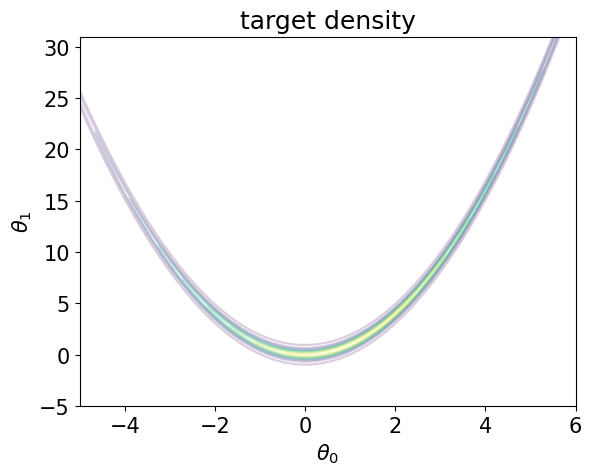

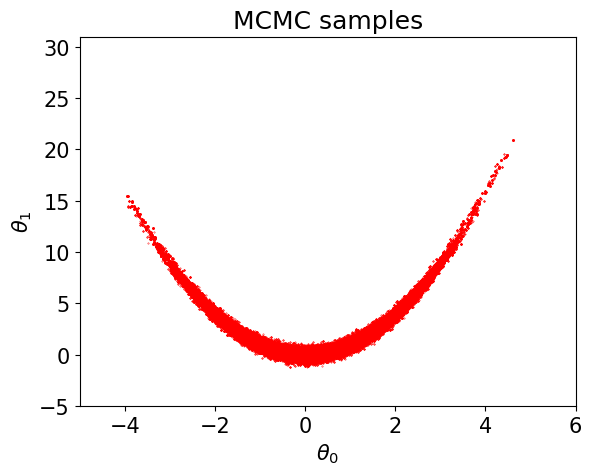

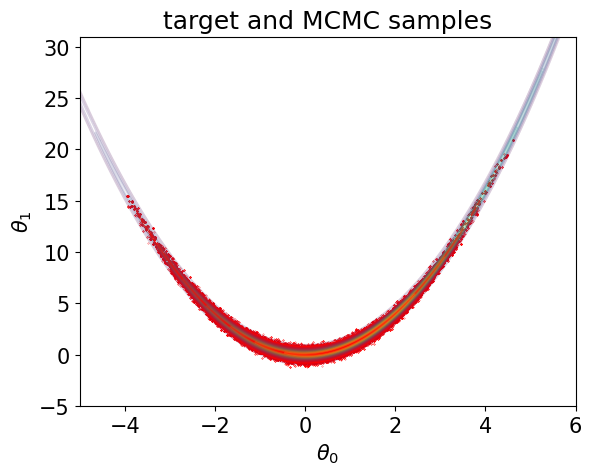

In [10]:
# plot the results...

# how many burnin steps to remove
burnin_steps = 100

# plot the target density
x = np.linspace(-5, 6, 500).astype(np.float32)
y = np.linspace(-5, 31, 500).astype(np.float32)
X, Y = np.meshgrid(x, y)
grid = torch.from_numpy(np.stack([X, Y], axis=-1))
L = torch.exp(log_prob(grid)).numpy()
plt.contour(x, y, L, levels = np.array([0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])*np.max(L.flatten()).astype(np.float64), alpha = 0.2)
plt.title('target density')
plt.xlabel('$\\theta_0$')
plt.ylabel('$\\theta_1$')
plt.show()

# scatter
plt.title('MCMC samples')
plt.scatter(chain.numpy()[burnin_steps:,:,0], chain.numpy()[burnin_steps:,:,1], s = 0.1, color = 'red')
plt.xlim(-5, 6)
plt.ylim(-5, 31)
plt.xlabel('$\\theta_0$')
plt.ylabel('$\\theta_1$')
plt.show()

# scatter + contours of target prob
plt.title('target and MCMC samples')
plt.contour(x, y, L, levels = np.array([0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])*np.max(L.flatten()).astype(np.float64), alpha = 0.2)
plt.scatter(chain.numpy()[burnin_steps:,:,0], chain.numpy()[burnin_steps:,:,1], s = 0.05, color = 'red')
plt.xlabel('$\\theta_0$')
plt.ylabel('$\\theta_1$')
plt.show()

## JAX

### Target log probability

In [11]:
# import jax affine
import jax
import jax.numpy as jnp
from affine.jax import sample

# target log probability
def log_prob(theta):
    # rosenbrock function
    return -jnp.divide(jnp.square(1. - theta[...,0]) + jnp.multiply(100., jnp.square(theta[...,1] - jnp.square(theta[...,0]))), 20.)

### Initialize the walkers

In [12]:
# number of parameters
n_params = 2

# number of walkers (note you'll end up with a total of 2*n_walkers for this parallel variant of the affine sampler)
n_walkers = 500

# initialize walkers and current state
walkers1 = jax.random.normal(jax.random.key(42), shape=(n_walkers, n_params))
walkers2 = jax.random.normal(jax.random.key(17), shape=(n_walkers, n_params))

### Run the sampler!

In [13]:
# number of MCMC steps to take (you'll end up with an MCMC chain with shape (n_steps, 2*n_walkers, n_parameters))
n_steps = 300

# run the sampler
chain = sample(jax.random.key(66), log_prob, n_steps, [walkers1, walkers2], args=[])

100%|█████████████████████████████████████| 299/299 [00:00<00:00, 340.53it/s]


### Plot the results

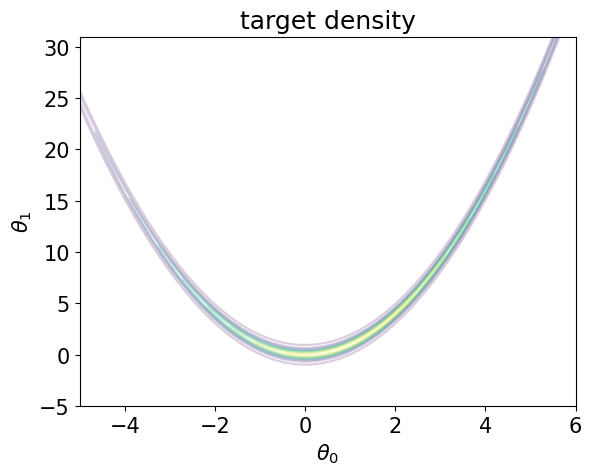

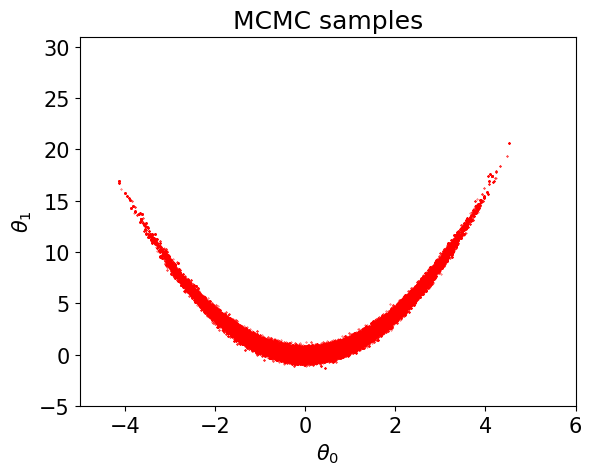

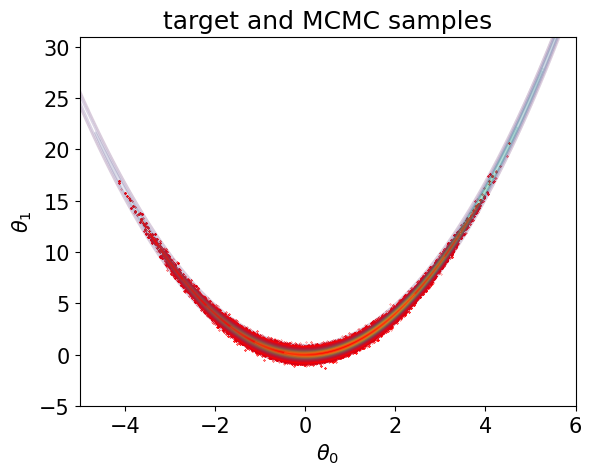

In [14]:
# plot the results...

# how many burnin steps to remove
burnin_steps = 100

# plot the target density
x = np.linspace(-5, 6, 500).astype(np.float32)
y = np.linspace(-5, 31, 500).astype(np.float32)
X, Y = np.meshgrid(x, y)
grid = np.stack([X, Y], axis=-1)
L = np.exp(log_prob(grid))
plt.contour(x, y, L, levels = np.array([0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])*np.max(L.flatten()).astype(np.float64), alpha = 0.2)
plt.title('target density')
plt.xlabel('$\\theta_0$')
plt.ylabel('$\\theta_1$')
plt.show()

# scatter
plt.title('MCMC samples')
plt.scatter(chain[burnin_steps:,:,0], chain[burnin_steps:,:,1], s = 0.1, color = 'red')
plt.xlim(-5, 6)
plt.ylim(-5, 31)
plt.xlabel('$\\theta_0$')
plt.ylabel('$\\theta_1$')
plt.show()

# scatter + contours of target prob
plt.title('target and MCMC samples')
plt.contour(x, y, L, levels = np.array([0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])*np.max(L.flatten()).astype(np.float64), alpha = 0.2)
plt.scatter(chain[burnin_steps:,:,0], chain[burnin_steps:,:,1], s = 0.05, color = 'red')
plt.xlabel('$\\theta_0$')
plt.ylabel('$\\theta_1$')
plt.show()